# Taller Análisis Exploratorio de Datos

***Juan Sebastian Garcia - Sebastian Hernandez***

## Paso 1: Carga de datos

Abra el archivo en Excel o bloc de notas, y revise sí hay algo particular con los datos. Este paso es importante para evitar problemas posteriores al cargar los datos.

Cargar el archivo dado, que contiene un dataset cuya información puede consultar en [IBM](https://community.ibm.com/community/user/businessanalytics/blogs/steven-macko/2019/07/11/telco-customer-churn-1113).

Responda las siguientes preguntas:

- ¿Cuántas filas y columnas tiene el dataframe?
- ¿De qué tipo de dato es cada columna?
- ¿Las variables están en el tipo de dato correcto para su contenido? A qué tipo de variable se debn cambiar si es necesario?


In [1]:
import pandas as pd

df = pd.read_csv(
    "../data/raw/Telco_customer_churn.csv",
    header=0,
    names=['CustomerID', 'Count', 'Country', 'State', 'City', 'Zip Code', 'Lat Long', 'Latitude', 'Longitude',
           'Gender', 'Senior Citizen', 'Partner', 'Dependents', 'Tenure Months', 'Phone Service',
           'Multiple Lines', 'Internet Service', 'Online Security', 'Online Backup', 'Device Protection',
           'Tech Support', 'Streaming TV', 'Streaming Movies', 'Contract', 'Paperless Billing',
           'Payment Method', 'Monthly Charges', 'Total Charges', 'Churn Label', 'Churn Value',
           'Churn Score', 'CLTV', 'Churn Reason'],
    na_values=[' ?', ' ']
)

df.head()

,CustomerID,Count,Country,State,City,Zip Code,Lat Long,Latitude,Longitude,Gender,...,Contract,Paperless Billing,Payment Method,Monthly Charges,Total Charges,Churn Label,Churn Value,Churn Score,CLTV,Churn Reason
0,3668-QPYBK,1,United States,California,Los Angeles,90003,"33.964131, -118.272783",33.964131,-118.272783,Male,...,Month-to-month,Yes,Mailed check,53.85,108.15,Yes,1,86,3239,Competitor made better offer
1,9237-HQITU,1,United States,California,Los Angeles,90005,"34.059281, -118.30742",34.059281,-118.307420,Female,...,Month-to-month,Yes,Electronic check,70.70,151.65,Yes,1,67,2701,Moved
2,9305-CDSKC,1,United States,California,Los Angeles,90006,"34.048013, -118.293953",34.048013,-118.293953,Female,...,Month-to-month,Yes,Electronic check,99.65,820.50,Yes,1,86,5372,Moved
3,7892-POOKP,1,United States,California,Los Angeles,90010,"34.062125, -118.315709",34.062125,-118.315709,Female,...,Month-to-month,Yes,Electronic check,104.80,3046.05,Yes,1,84,5003,Moved
4,0280-XJGEX,1,United States,California,Los Angeles,90015,"34.039224, -118.266293",34.039224,-118.266293,Male,...,Month-to-month,Yes,Bank transfer (automatic),103.70,5036.30,Yes,1,89,5340,Competitor had better devices


In [2]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 33 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   CustomerID         7043 non-null   object 
 1   Count              7043 non-null   int64  
 2   Country            7043 non-null   object 
 3   State              7043 non-null   object 
 4   City               7043 non-null   object 
 5   Zip Code           7043 non-null   int64  
 6   Lat Long           7043 non-null   object 
 7   Latitude           7043 non-null   float64
 8   Longitude          7043 non-null   float64
 9   Gender             7043 non-null   object 
 10  Senior Citizen     7043 non-null   object 
 11  Partner            7043 non-null   object 
 12  Dependents         7043 non-null   object 
 13  Tenure Months      7043 non-null   int64  
 14  Phone Service      7043 non-null   object 
 15  Multiple Lines     7043 non-null   object 
 16  Internet Service   7043 

### Respuestas - Paso 1

- **¿Cuántas filas y columnas tiene el dataframe?**
  El dataframe tiene **7043 filas** y **33 columnas**.

- **¿De qué tipo de dato es cada columna?**
  - `int64` (6 columnas): `Count`, `Zip Code`, `Tenure Months`, `Churn Value`, `Churn Score`, `CLTV`.
  - `float64` (4 columnas): `Latitude`, `Longitude`, `Monthly Charges`, `Total Charges`.
  - `object` (23 columnas): `CustomerID`, `Country`, `State`, `City`, `Lat Long`, `Gender`, `Senior Citizen`, `Partner`, `Dependents`, `Phone Service`, `Multiple Lines`, `Internet Service`, `Online Security`, `Online Backup`, `Device Protection`, `Tech Support`, `Streaming TV`, `Streaming Movies`, `Contract`, `Paperless Billing`, `Payment Method`, `Churn Label`, `Churn Reason`.

- **¿Las variables están en el tipo de dato correcto?**
  No todas. Se identifican los siguientes problemas:
  - `Total Charges` es `float64` pero tiene **11 valores nulos** (7032 non-null de 7043). En el archivo original venía como texto (`object`) debido a valores en blanco (`" "`), los cuales fueron tratados como `NaN` gracias al parámetro `na_values`. Pandas la convirtió correctamente a `float64`, pero hay que tener en cuenta esos 11 registros faltantes.
  - `Zip Code` es `int64` pero creemos que debería tratarse como **categórica** (`object` o `category`), ya que un código postal es un identificador geográfico, no una cantidad medible.

In [24]:
df["Zip Code"] = df["Zip Code"].astype("category")

## Paso 2: Exploración inicial de los datos

Responda las siguientes preguntas:

- ¿Hay valores fuera de rango o imposibles, según el dominio del problema?
- ¿Hay variables que no varían?
- Qué variables *cualitativas* tienen muchos valores únicos (alta cardinalidad)?
- ¿Hay claves primarias o identificadores únicos?

In [ ]:
df.describe()

,Count,Zip Code,Latitude,Longitude,Tenure Months,Monthly Charges,Total Charges,Churn Value,Churn Score,CLTV
count,7043.0,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7032.000000,7043.000000,7043.000000,7043.000000
mean,1.0,93521.964646,36.282441,-119.798880,32.371149,64.761692,2283.300441,0.265370,58.699418,4400.295755
std,0.0,1865.794555,2.455723,2.157889,24.559481,30.090047,2266.771362,0.441561,21.525131,1183.057152
min,1.0,90001.000000,32.555828,-124.301372,0.000000,18.250000,18.800000,0.000000,5.000000,2003.000000
25%,1.0,92102.000000,34.030915,-121.815412,9.000000,35.500000,401.450000,0.000000,40.000000,3469.000000
50%,1.0,93552.000000,36.391777,-119.730885,29.000000,70.350000,1397.475000,0.000000,61.000000,4527.000000
75%,1.0,95351.000000,38.224869,-118.043237,55.000000,89.850000,3794.737500,1.000000,75.000000,5380.500000
max,1.0,96161.000000,41.962127,-114.192901,72.000000,118.750000,8684.800000,1.000000,100.000000,6500.000000


In [ ]:
df.describe(include='object')

,CustomerID,Country,State,City,Lat Long,Gender,Senior Citizen,Partner,Dependents,Phone Service,...,Online Backup,Device Protection,Tech Support,Streaming TV,Streaming Movies,Contract,Paperless Billing,Payment Method,Churn Label,Churn Reason
count,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,...,7043,7043,7043,7043,7043,7043,7043,7043,7043,1869
unique,7043,1,1,1129,1652,2,2,2,2,2,...,3,3,3,3,3,3,2,4,2,20
top,3668-QPYBK,United States,California,Los Angeles,"34.159534, -116.425984",Male,No,No,No,Yes,...,No,No,No,No,No,Month-to-month,Yes,Electronic check,No,Attitude of support person
freq,1,7043,7043,305,5,3555,5901,3641,5416,6361,...,3088,3095,3473,2810,2785,3875,4171,2365,5174,192


In [ ]:
for col in df.select_dtypes(include=["object"]).columns:
    print(f'La columna "{col}" tiene {df[col].nunique()} categorías únicas: \n {df[col].unique()} \n')

La columna "CustomerID" tiene 7043 categorías únicas: 
 ['3668-QPYBK' '9237-HQITU' '9305-CDSKC' ... '2234-XADUH' '4801-JZAZL'
 '3186-AJIEK'] 

La columna "Country" tiene 1 categorías únicas: 
 ['United States'] 

La columna "State" tiene 1 categorías únicas: 
 ['California'] 

La columna "City" tiene 1129 categorías únicas: 
 ['Los Angeles' 'Beverly Hills' 'Huntington Park' ... 'Standish' 'Tulelake'
 'Olympic Valley'] 

La columna "Lat Long" tiene 1652 categorías únicas: 
 ['33.964131, -118.272783' '34.059281, -118.30742' '34.048013, -118.293953'
 ... '40.346634, -120.386422' '41.813521, -121.492666'
 '39.191797, -120.212401'] 

La columna "Gender" tiene 2 categorías únicas: 
 ['Male' 'Female'] 

La columna "Senior Citizen" tiene 2 categorías únicas: 
 ['No' 'Yes'] 

La columna "Partner" tiene 2 categorías únicas: 
 ['No' 'Yes'] 

La columna "Dependents" tiene 2 categorías únicas: 
 ['No' 'Yes'] 

La columna "Phone Service" tiene 2 categorías únicas: 
 ['Yes' 'No'] 

La columna "Multip

### Respuestas - Paso 2

- **¿Hay valores fuera de rango o imposibles?**
  No se detectan valores fuera de rango ni imposibles en las variables numéricas:
  - `Tenure Months` va de 0 a 72 lo cual me parece razonable para meses de permanencia.
  - `Monthly Charges` va de \$18.25 a \$118.75, valores que son bastante consistententes con los precios de compañías de telecomunicaciones.
  - `Total Charges` va de \$18.80 a \$8684.80 lo cual es consistente con la antiguedad y cobro mensual.
  - En general, todas las variables tienen valores razonablees.

- **¿Hay variables que no varían?**
  Sí, se identifican **3 variables constantes**:
  - `Count`: siempre vale **1**.
  - `Country`: siempre es **"United States"**.
  - `State`: siempre es **"California"**.
  Estas variables se deberían descartar porque no aportan información relevante.

- **¿Qué variables cualitativas tienen alta cardinalidad?**
  - `CustomerID`: 7043 valores únicos.
  - `City`: 1129 ciudades distintas.
  - `Zip Code`: 1652 códigos postales distintos.
  - `Lat Long`: 1652 ubicaciones únicas.
  - `Churn Reason`: 20 categorías distintas.
  Las demás variables categóricas tienen baja cardinalidad porque tienen solo entre 2 y 4 categorías.

- **¿Hay claves primarias o identificadores únicos?**
  Sí. `CustomerID` es la clave primaria ya que tiene 7043 valores únicos, exactamente igual al número de filas, por lo que identifica a cada cliente inequivocamente.

## Paso 3: Identificación de datos duplicados, datos nulos y problemas de formateo

Descarte las variables que solo toman un valor y las que son clave primaria. También descarte las variables **City** y **Lat Long**.

Responda las siguientes preguntas:

- ¿Qué variables tienen valores nulos? ¿En qué proporción?
- ¿Hay registros duplicados?
- ¿Hay variables con problemas de formateo (fechas, monedas, mayúsculas/minúsculas)?

In [ ]:
cols_to_drop = ['CustomerID', 'Count', 'Country', 'State', 'City', 'Lat Long']
df = df.drop(columns=[col for col in cols_to_drop if col in df.columns])

df['Total Charges'] = pd.to_numeric(df['Total Charges'], errors='coerce')

In [11]:
df.isnull().sum().sort_values(ascending=False)*100/df.shape[0]

Churn Reason         73.463013
Total Charges         0.156183
Zip Code              0.000000
Gender                0.000000
Senior Citizen        0.000000
Partner               0.000000
Dependents            0.000000
Tenure Months         0.000000
Phone Service         0.000000
Latitude              0.000000
Longitude             0.000000
Internet Service      0.000000
Multiple Lines        0.000000
Online Security       0.000000
Online Backup         0.000000
Streaming TV          0.000000
Streaming Movies      0.000000
Device Protection     0.000000
Tech Support          0.000000
Paperless Billing     0.000000
Contract              0.000000
Monthly Charges       0.000000
Payment Method        0.000000
Churn Label           0.000000
Churn Value           0.000000
Churn Score           0.000000
CLTV                  0.000000
dtype: float64

In [12]:
print('Número de registros duplicados: ', df.duplicated().sum())

Número de registros duplicados:  0


### Respuestas - Paso 3

- **¿Qué variables tienen valores nulos? ¿En qué proporción?**
  Después de descartar las columnas indicadas (`CustomerID`, `Count`, `Country`, `State`, `City`, `Lat Long`) y convertir `Total Charges` a numérico:
  - `Churn Reason`: 5174 nulos (73.46%). Corresponde a los clientes que no hicieron churn entonces es un nulo válido.
  - `Total Charges`: 11 nulos (0.16%). Son registros que originalmente contenían cadenas en blanco (" ") y que al convertir a numérico con `pd.to_numeric()` quedaron como `NaN`. Al revisar los datos, estos 11 registros corresponden a clientes con `Tenure Months = 0`, es decir, clientes recién ingresados que aún no acumulan cargos.

- **¿Hay registros duplicados?**
  No. El dataset tiene 0 registros duplicados.

- **¿Hay variables con problemas de formateo?**
  - `Total Charges` estaba como tipo `object` (texto) en el archivo original debido a registros con valores en blanco. Se aplicó `na_values=[' ?', ' ']` al cargar los datos, lo que permitió a Pandas interpretar esos blancos como nulos, y la columna se cargó directamente como `float64` pero de todas maneras se confirmó la conversión numérica con `pd.to_numeric()`.
  - No vimos ningún otro problema de formateo.

## Paso 4: Análisis de variables cuantitativas

Haga análisis de normalidad de las variables cuantitativas. Indique cuáles variables cumplen con el supuesto de normalidad y cuáles no.

Haga un análisis gráfico de outliers, y como resultado de este indique que variables tienen datos atípicos.

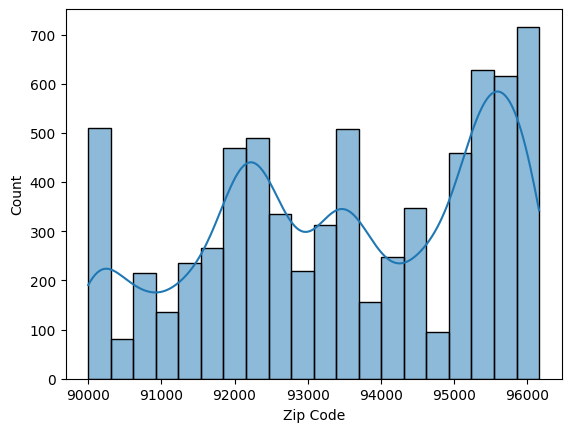

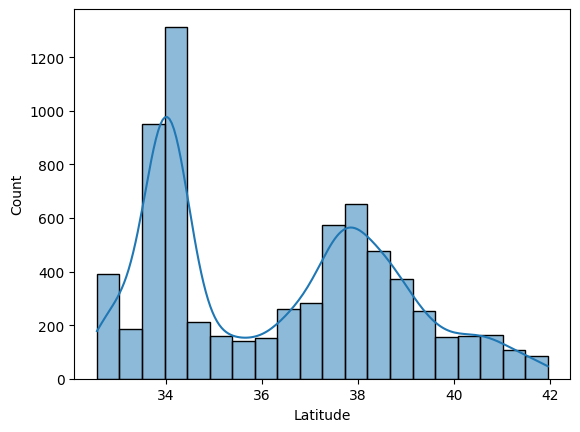

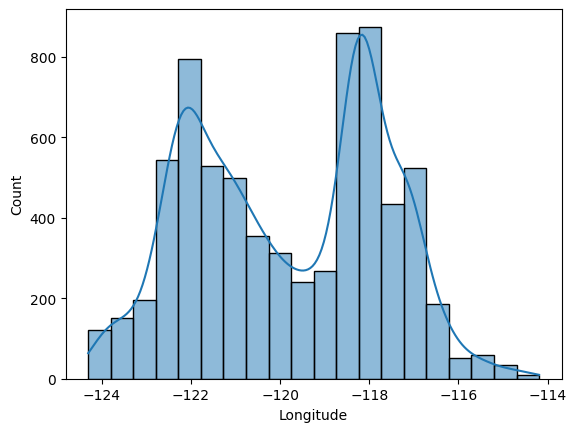

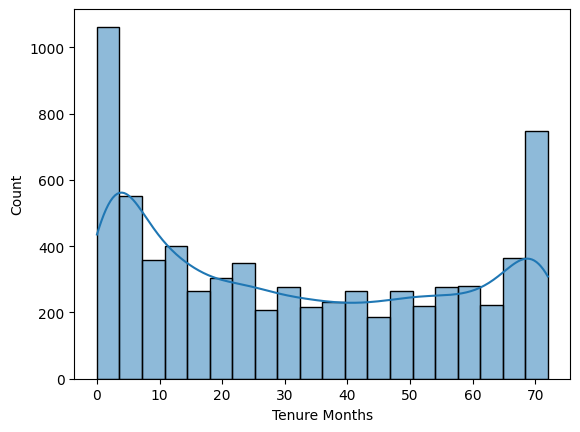

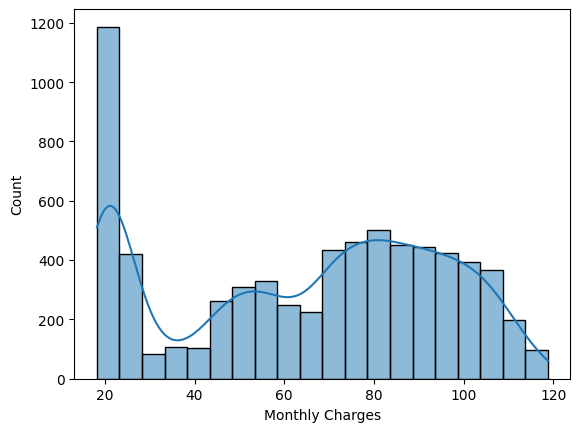

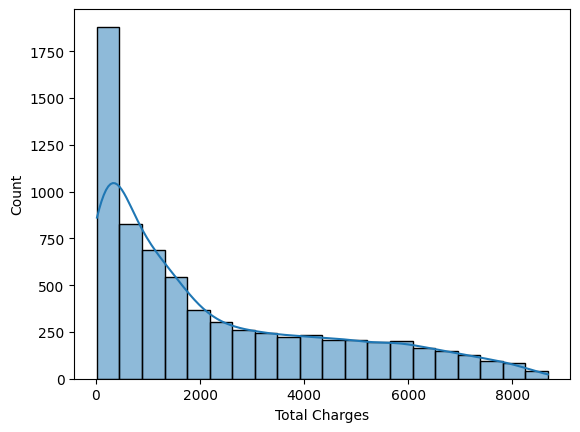

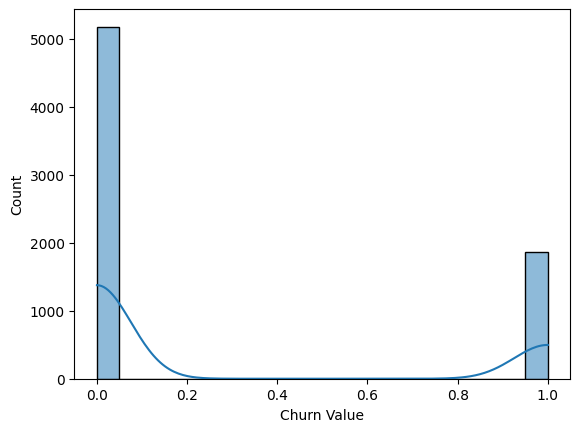

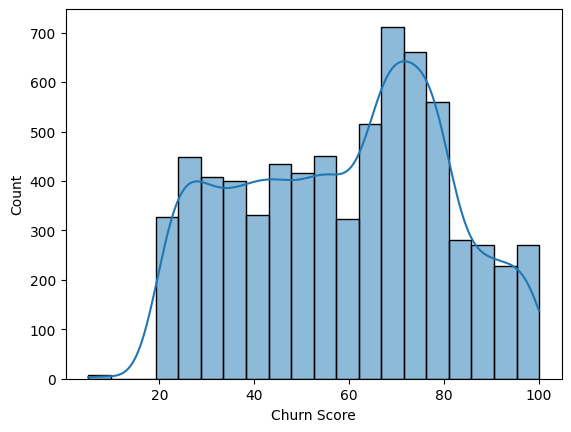

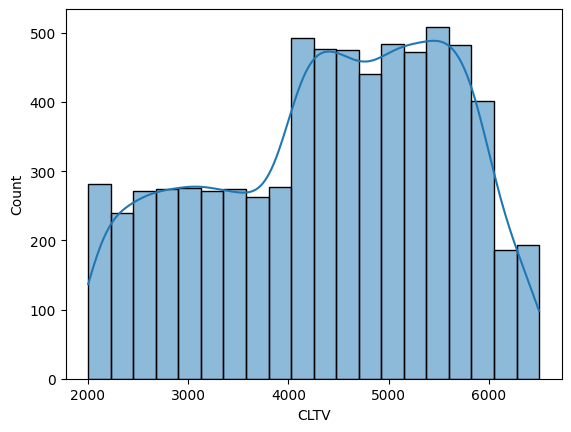

In [13]:
import matplotlib.pyplot as plt
import seaborn as sns

for col in df.select_dtypes(include=['number']).columns:
    plt.figure()
    sns.histplot(data=df, x=col, bins=20, kde=True)
    plt.show()

In [14]:
for num in df.select_dtypes(include=['number']).columns:
    print(f"Asimetría de {num}: {df[num].skew():.3f} \n")

Asimetría de Zip Code: -0.251 

Asimetría de Latitude: 0.304 

Asimetría de Longitude: -0.041 

Asimetría de Tenure Months: 0.240 

Asimetría de Monthly Charges: -0.221 

Asimetría de Total Charges: 0.962 

Asimetría de Churn Value: 1.063 

Asimetría de Churn Score: -0.090 

Asimetría de CLTV: -0.312 



In [15]:
for num in df.select_dtypes(include=['number']).columns:
    print(f"Kurtosis de {num}: {df[num].kurt():.3f} \n")

Kurtosis de Zip Code: -1.154 

Kurtosis de Latitude: -1.136 

Kurtosis de Longitude: -1.136 

Kurtosis de Tenure Months: -1.387 

Kurtosis de Monthly Charges: -1.257 

Kurtosis de Total Charges: -0.232 

Kurtosis de Churn Value: -0.870 

Kurtosis de Churn Score: -1.006 

Kurtosis de CLTV: -0.934 



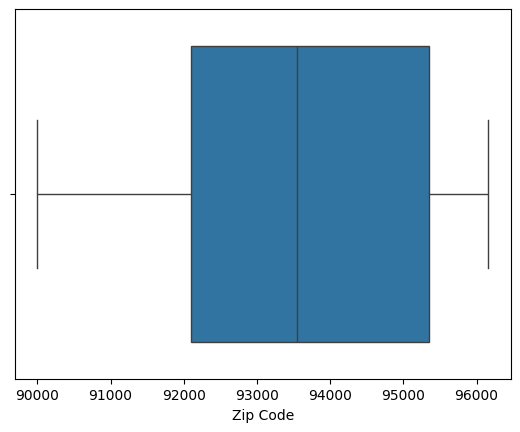

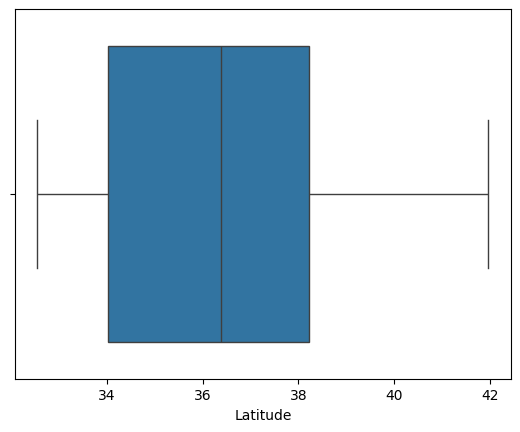

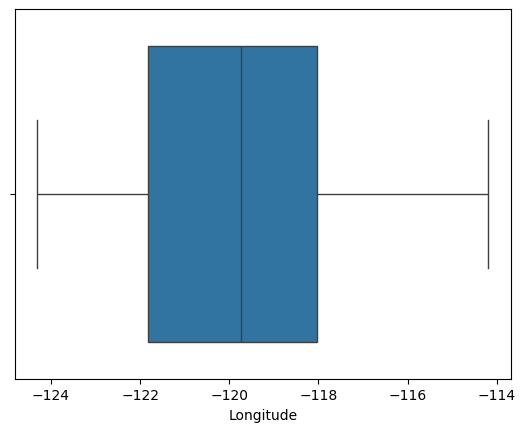

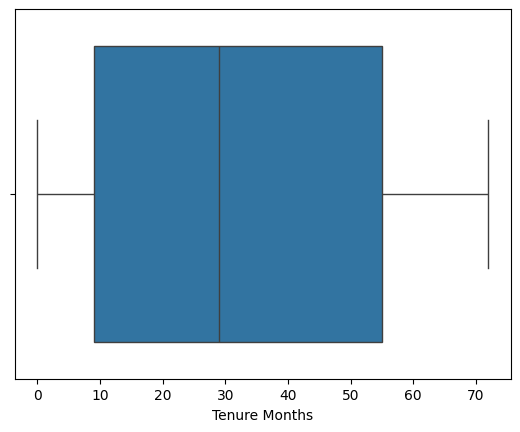

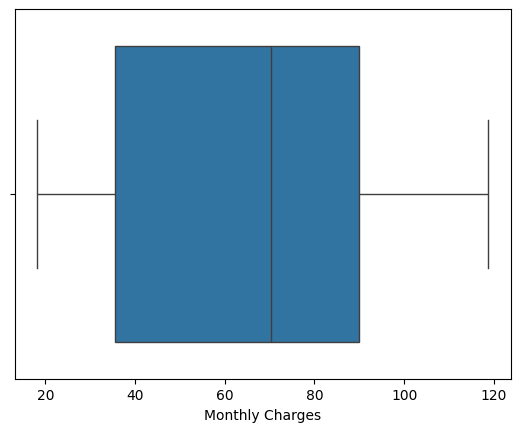

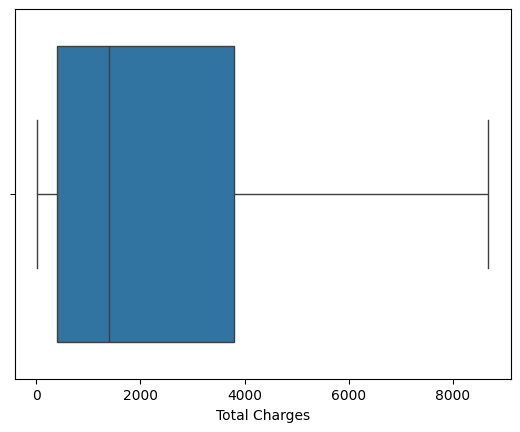

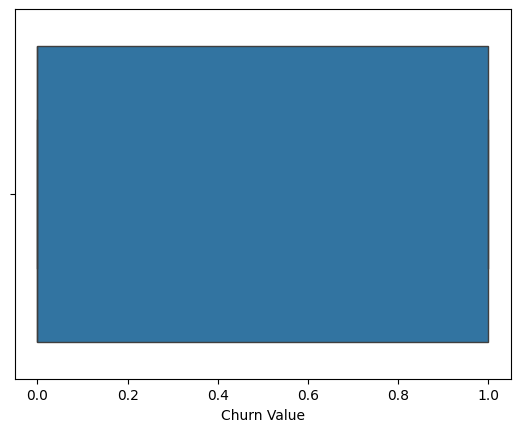

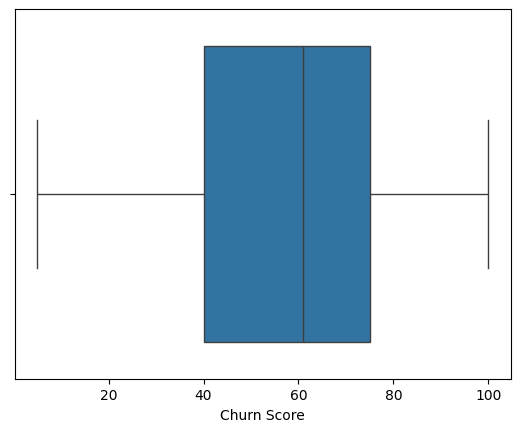

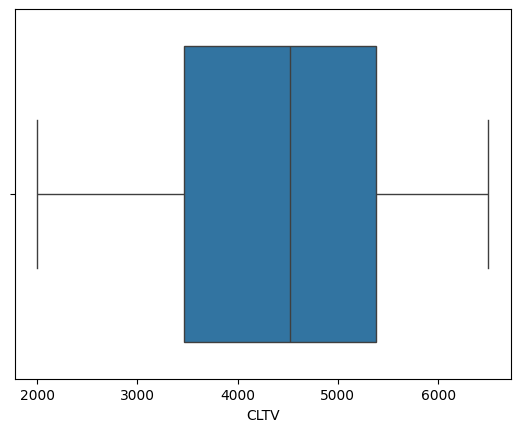

In [16]:
for num in df.select_dtypes(include=['number']).columns:
    plt.figure()
    sns.boxplot(data=df, x=num)
    plt.show();

### Respuestas - Paso 4

Ninguna variable cuantitativa cumple el supuesto de normalidad: todas presentan curtosis negativa (distribuciones más planas que la normal), Total Charges es la más asimétrica (skew = 0.962) con un fuerte sesgo a la derecha, mientras que Churn Value es binaria y no aplica. En cuanto a outliers, ninguna variable presenta valores atípicos según el método IQR, ya que los rangos intercuartílicos son lo suficientemente amplios para contener todos los datos, lo que se confirma visualmente en los boxplots.

## Paso 5: Análisis de variables cualitativas

Responda a las siguientes preguntas:

- ¿Cómo se comportan las variables categóricas?
- ¿Existen variables de alta cardinalidad?
- ¿Existen categorías atípicas?

In [17]:
cat_vars = df.select_dtypes(include=['object']).columns

for var in cat_vars:
    print(f'El conteo de la variable {var} es: \n {df[var].value_counts()} \n')

El conteo de la variable Gender es: 
 Gender
Male      3555
Female    3488
Name: count, dtype: int64 

El conteo de la variable Senior Citizen es: 
 Senior Citizen
No     5901
Yes    1142
Name: count, dtype: int64 

El conteo de la variable Partner es: 
 Partner
No     3641
Yes    3402
Name: count, dtype: int64 

El conteo de la variable Dependents es: 
 Dependents
No     5416
Yes    1627
Name: count, dtype: int64 

El conteo de la variable Phone Service es: 
 Phone Service
Yes    6361
No      682
Name: count, dtype: int64 

El conteo de la variable Multiple Lines es: 
 Multiple Lines
No                  3390
Yes                 2971
No phone service     682
Name: count, dtype: int64 

El conteo de la variable Internet Service es: 
 Internet Service
Fiber optic    3096
DSL            2421
No             1526
Name: count, dtype: int64 

El conteo de la variable Online Security es: 
 Online Security
No                     3498
Yes                    2019
No internet service    1526
Name:

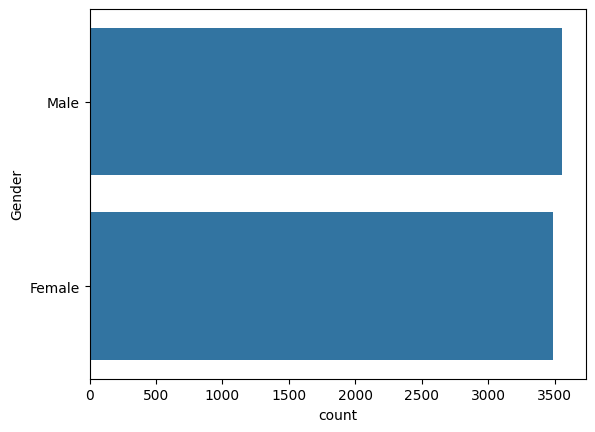

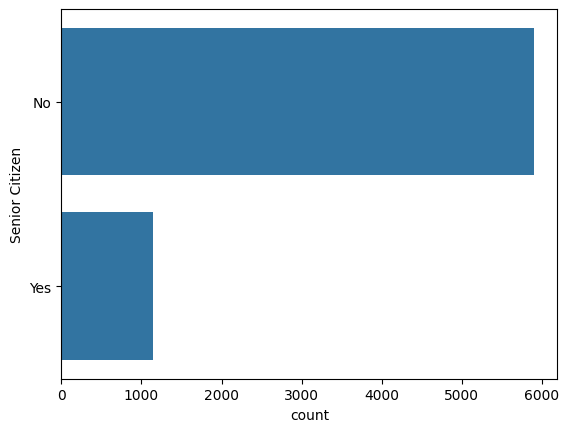

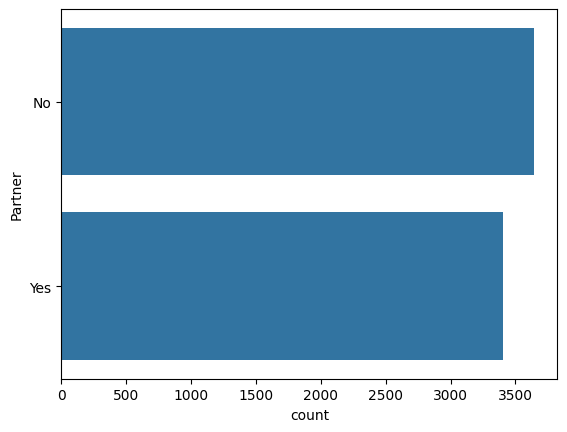

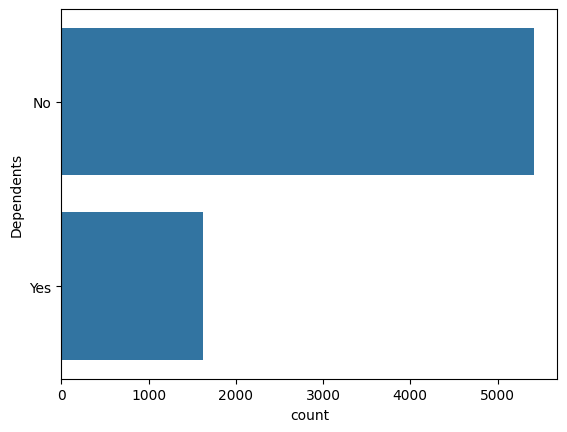

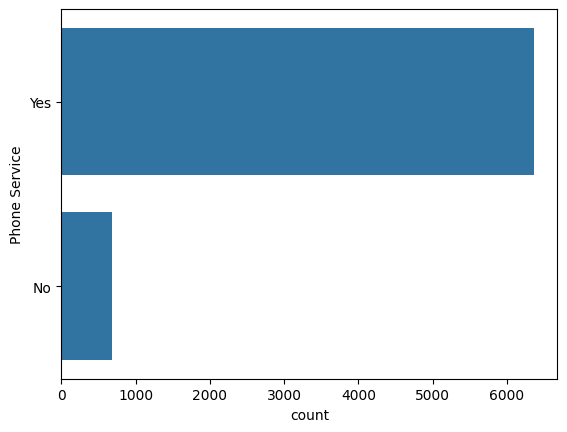

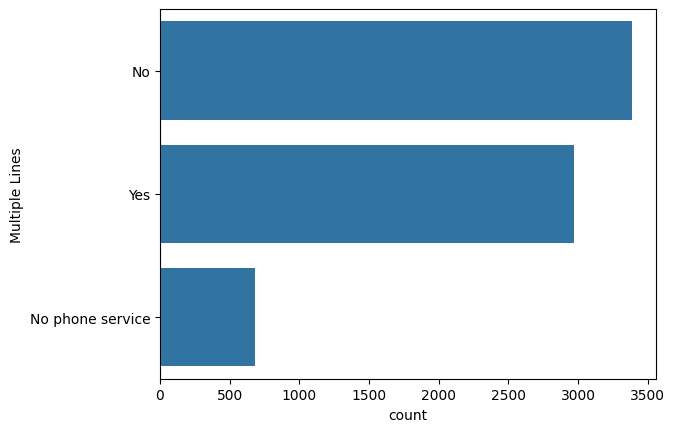

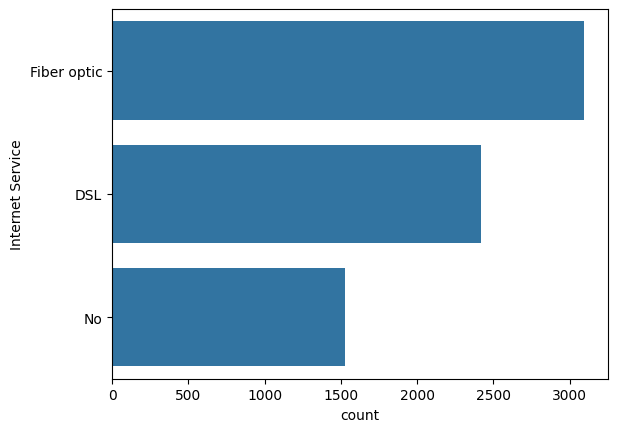

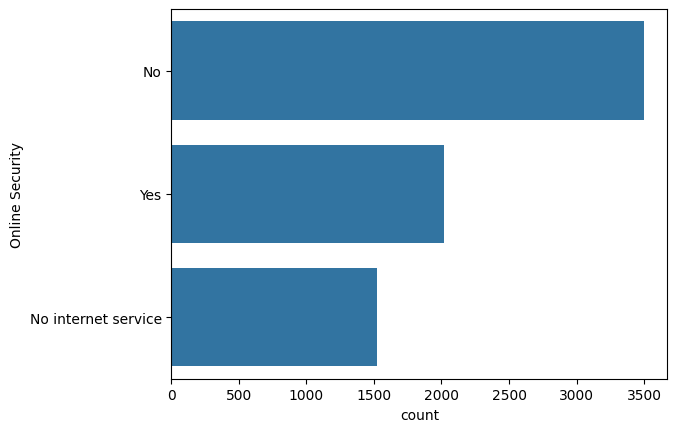

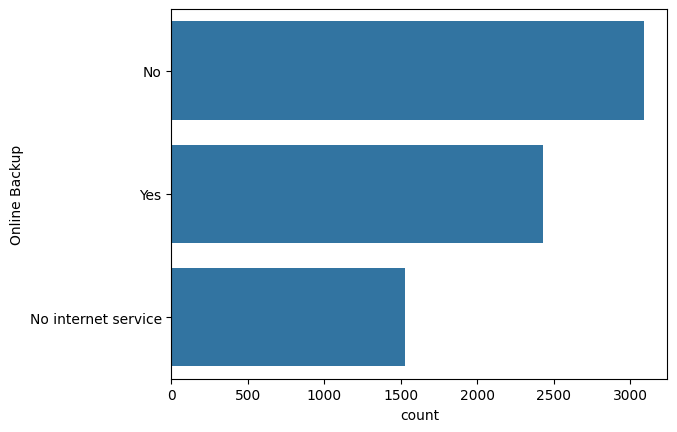

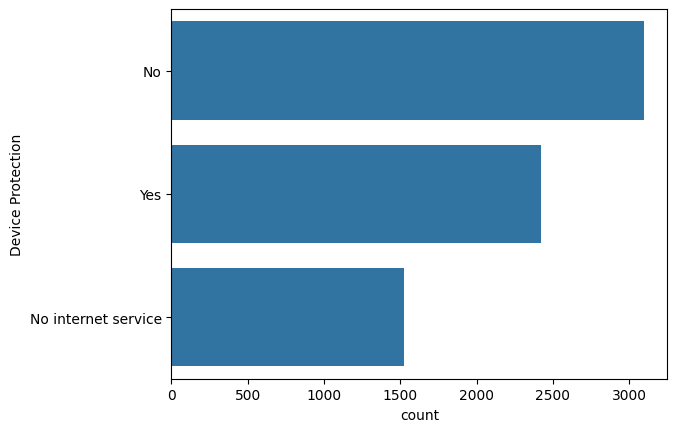

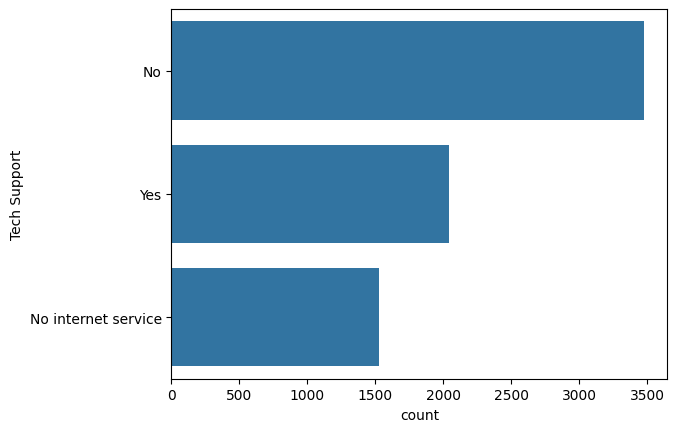

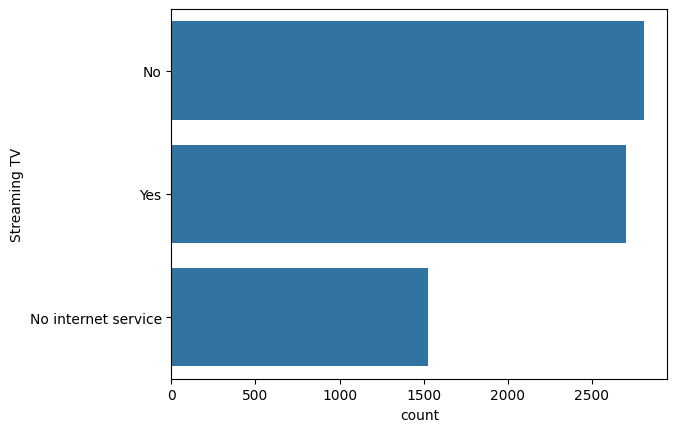

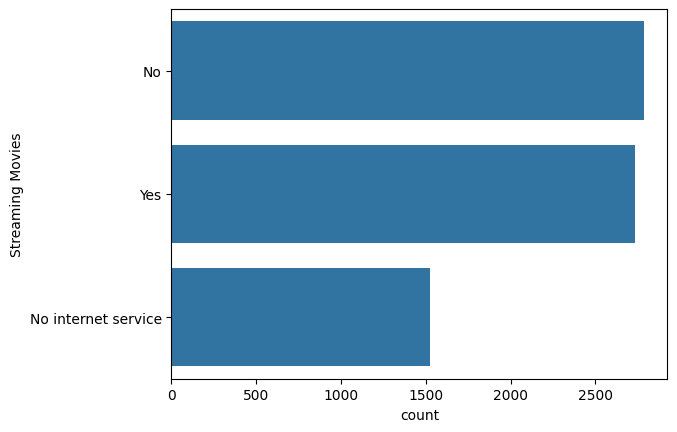

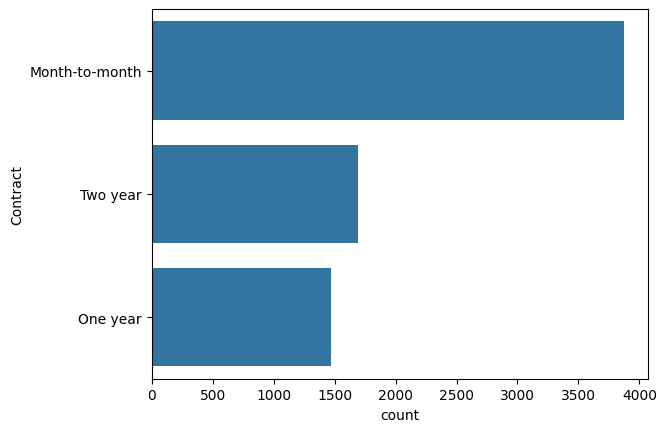

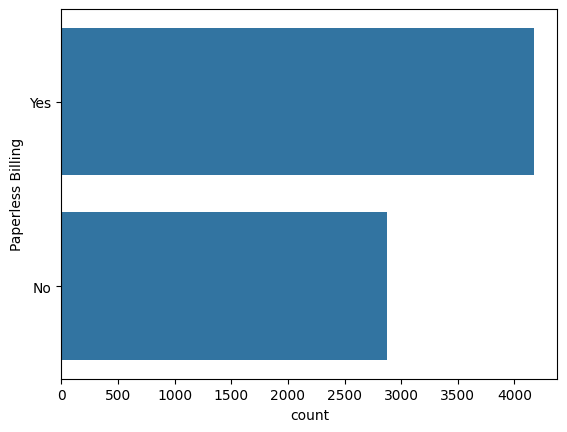

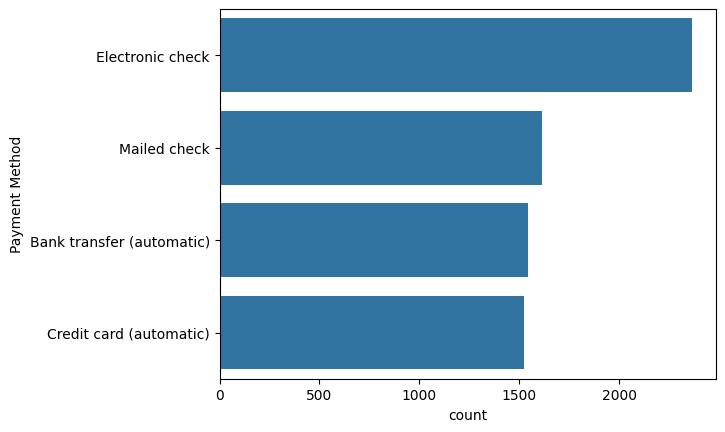

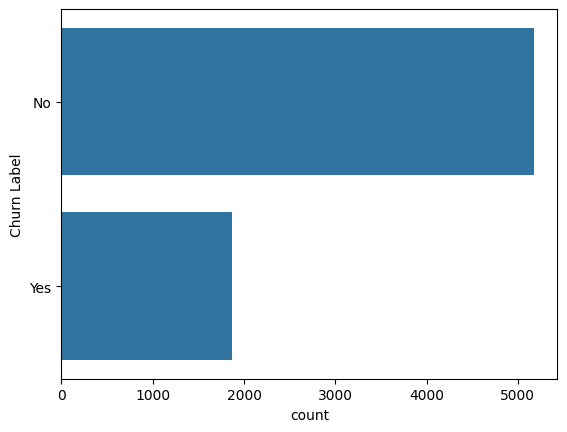

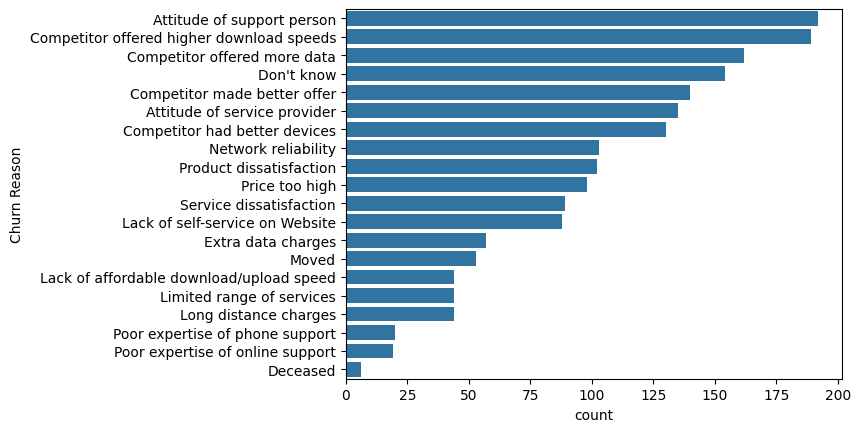

In [18]:
for cat in df.select_dtypes(include=['object']).columns:
    plt.figure()
    sns.countplot(data=df, y=cat, order=df[cat].value_counts().index)
    plt.show();

### Respuestas - Paso 5

La mayoría de variables categóricas tienen baja cardinalidad (2 a 4 categorías) y distribuciones razonablemente interpretables: Gender está casi balanceada, mientras que Senior Citizen (16.2% Yes), Dependents (23.1% Yes) y Phone Service (90.3% Yes) están desbalanceadas. Contract tiene predominio de contratos mes a mes (55%) y Churn Label está desbalanceada con 73.5% de clientes que no hicieron churn. La única variable de alta cardinalidad es Churn Reason con 20 categorías, aunque solo tiene registros para los 1869 clientes que sí se retiraron. No se observan categorías atípicas ni errores de escritura.

## Paso 6: Análisis bivariado.

Se va a suponer que con este archivo de datos se desea hacer un modelo de aprendizaje de máquina que prediga la **Churn Value**.


Mediante análisis de gráficas responda las siguientes preguntas:

- ¿Cómo se relaciona cada una de las variables cuantitativas con la variable que se desea predecir?
- ¿Cómo se relaciona cada una de las variables cualitativas con la variable que se desea predecir?
- De acuerdo con estos análisis, ¿cuáles variables parecerían ser buenas predictoras, y cuáles no?


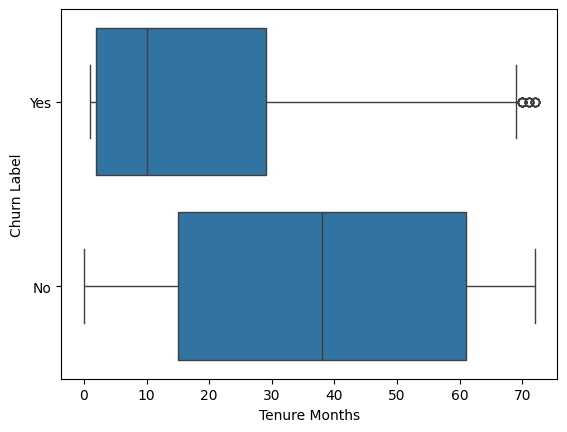

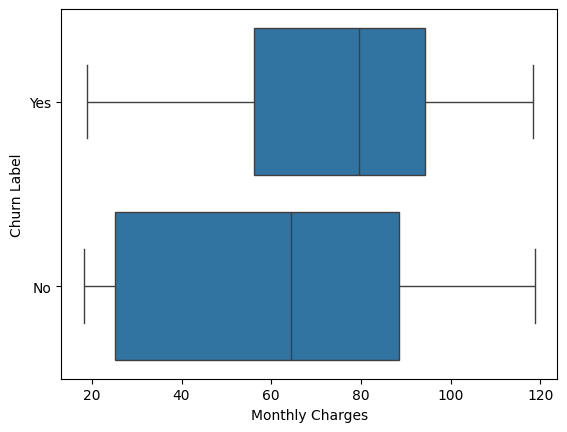

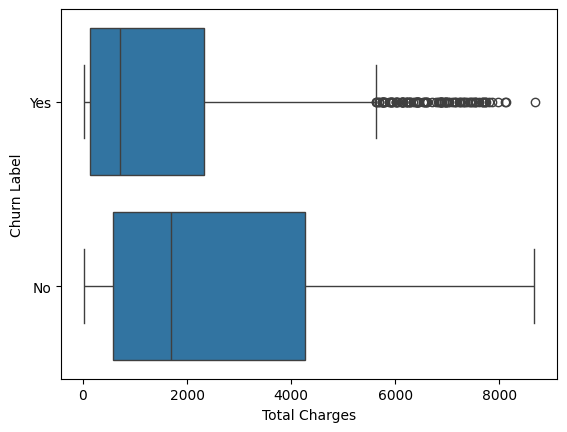

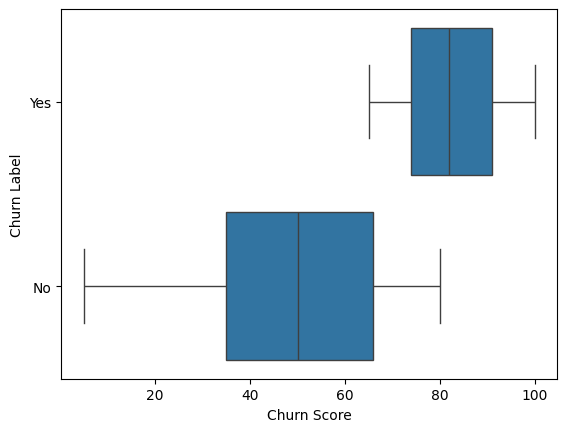

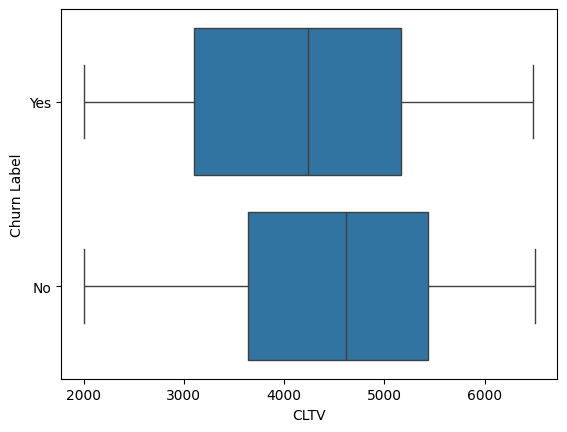

In [19]:
# Relación entre variables cuantitativas y Churn Label (variable objetivo)
for num in ['Tenure Months', 'Monthly Charges', 'Total Charges', 'Churn Score', 'CLTV']:
    plt.figure()
    sns.boxplot(data=df, y='Churn Label', x=num)
    plt.show()

In [20]:
df.groupby('Churn Label')[['Tenure Months', 'Monthly Charges', 'Total Charges', 'Churn Score', 'CLTV']].describe()

Tenure Months                                                     \
                    count       mean        std  min   25%   50%   75%   max   
Churn Label                                                                    
No                 5174.0  37.569965  24.113777  0.0  15.0  38.0  61.0  72.0   
Yes                1869.0  17.979133  19.531123  1.0   2.0  10.0  29.0  72.0   

            Monthly Charges             ... Churn Score           CLTV  \
                      count       mean  ...         75%    max   count   
Churn Label                             ...                              
No                   5174.0  61.265124  ...        66.0   80.0  5174.0   
Yes                  1869.0  74.441332  ...        91.0  100.0  1869.0   

                                                                         \
                    mean          std     min      25%     50%      75%   
Churn Label                                                               
No           4490.921337  1167.703198  2003.0  3643.75  4620.0  5434.75   
Yes          4149.414660  1189.370707  2003.0  3101.00  4238.0  5166.00   

                     
                max  
Churn Label          
No           6500.0  
Yes          6484.0  

[2 rows x 40 columns]

In [21]:
df.select_dtypes('number').corr()

,Zip Code,Latitude,Longitude,Tenure Months,Monthly Charges,Total Charges,Churn Value,Churn Score,CLTV
Zip Code,1.000000,0.895743,-0.784271,0.001041,-0.004596,-0.001462,0.003346,-0.002769,-0.003562
Latitude,0.895743,1.000000,-0.876779,-0.001631,-0.019899,-0.010313,-0.003384,-0.007684,0.000886
Longitude,-0.784271,-0.876779,1.000000,-0.001678,0.024098,0.009047,0.004594,0.004260,0.000485
Tenure Months,0.001041,-0.001631,-0.001678,1.000000,0.247900,0.825880,-0.352229,-0.224987,0.396406
Monthly Charges,-0.004596,-0.019899,0.024098,0.247900,1.000000,0.651065,0.193356,0.133754,0.098693
Total Charges,-0.001462,-0.010313,0.009047,0.825880,0.651065,1.000000,-0.199484,-0.124312,0.341837
Churn Value,0.003346,-0.003384,0.004594,-0.352229,0.193356,-0.199484,1.000000,0.664897,-0.127463
Churn Score,-0.002769,-0.007684,0.004260,-0.224987,0.133754,-0.124312,0.664897,1.000000,-0.079782
CLTV,-0.003562,0.000886,0.000485,0.396406,0.098693,0.341837,-0.127463,-0.079782,1.000000


<Axes: >

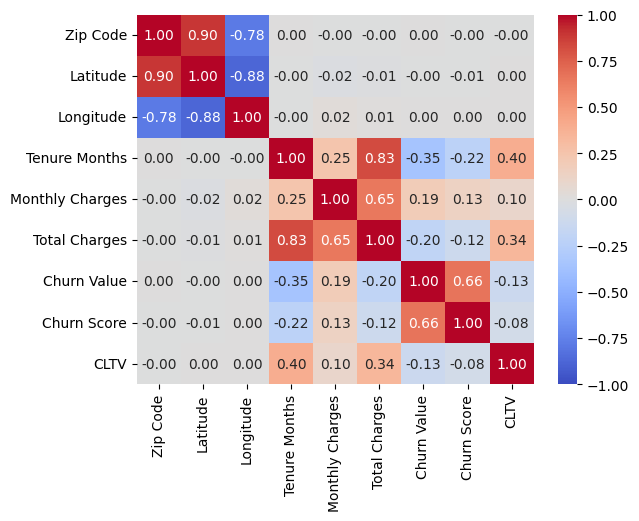

In [22]:
corr = df.select_dtypes('number').corr()
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', vmin=-1, vmax=1)


Variable: Gender
Churn Label        No       Yes
Gender                         
Female       0.730791  0.269209
Male         0.738397  0.261603


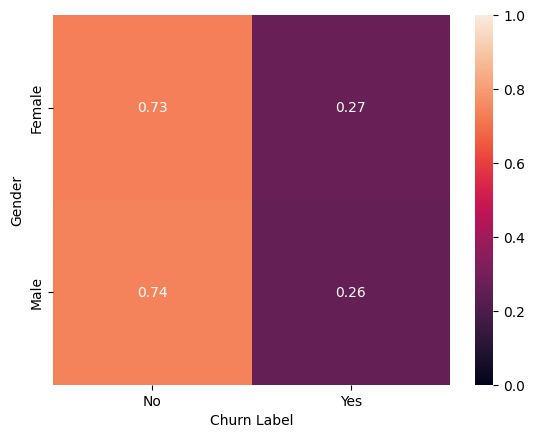

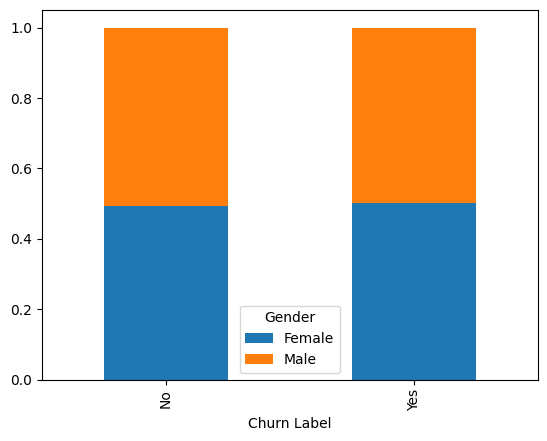


Variable: Senior Citizen
Churn Label           No       Yes
Senior Citizen                    
No              0.763938  0.236062
Yes             0.583187  0.416813


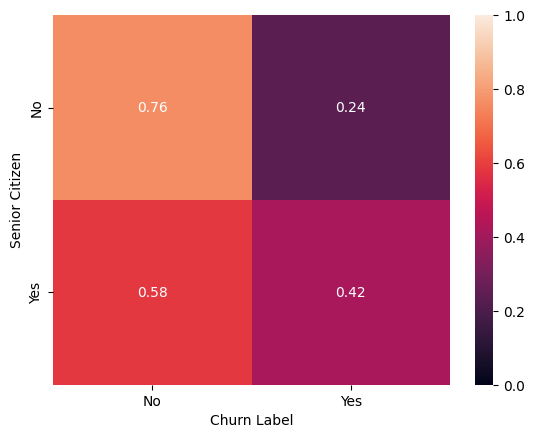

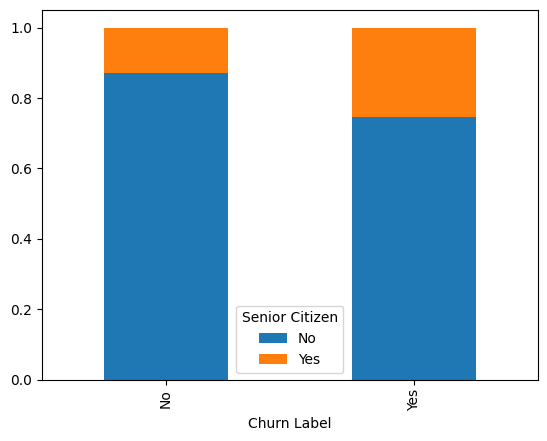


Variable: Partner
Churn Label        No       Yes
Partner                        
No           0.670420  0.329580
Yes          0.803351  0.196649


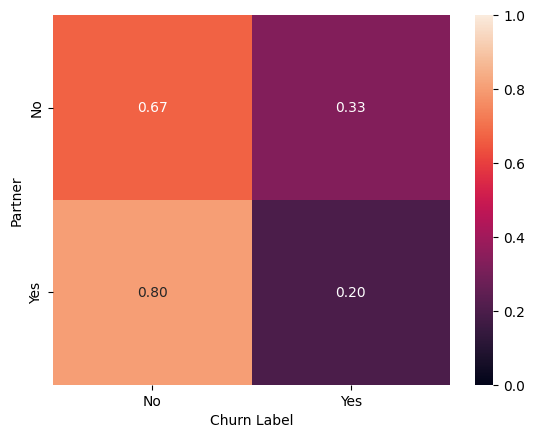

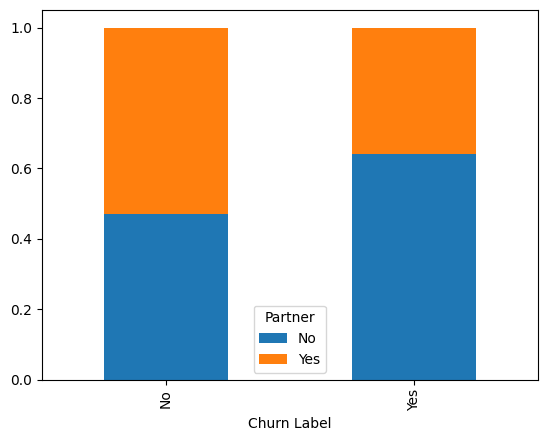


Variable: Dependents
Churn Label        No       Yes
Dependents                     
No           0.674483  0.325517
Yes          0.934849  0.065151


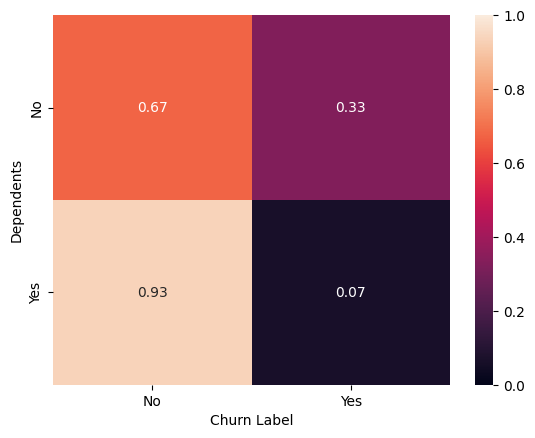

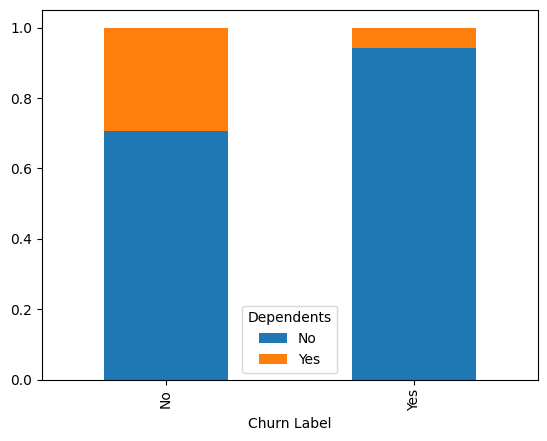


Variable: Phone Service
Churn Label          No       Yes
Phone Service                    
No             0.750733  0.249267
Yes            0.732904  0.267096


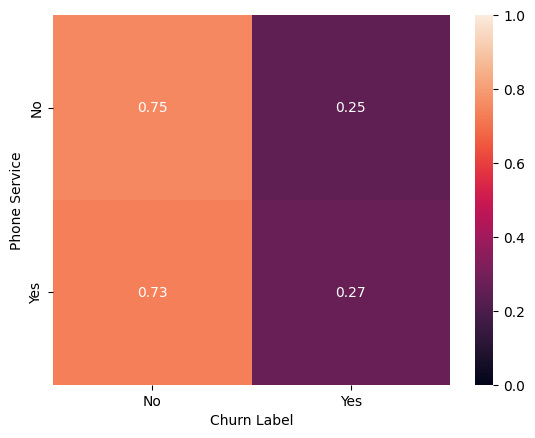

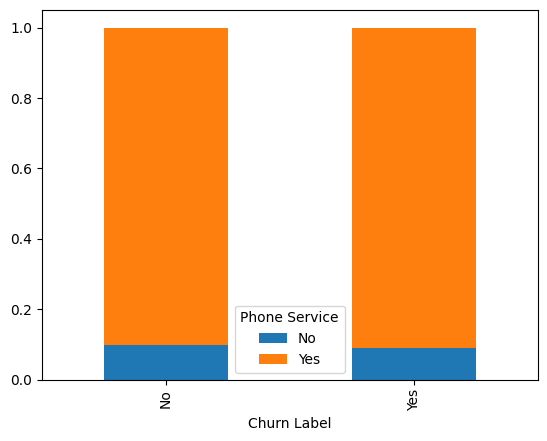


Variable: Multiple Lines
Churn Label             No       Yes
Multiple Lines                      
No                0.749558  0.250442
No phone service  0.750733  0.249267
Yes               0.713901  0.286099


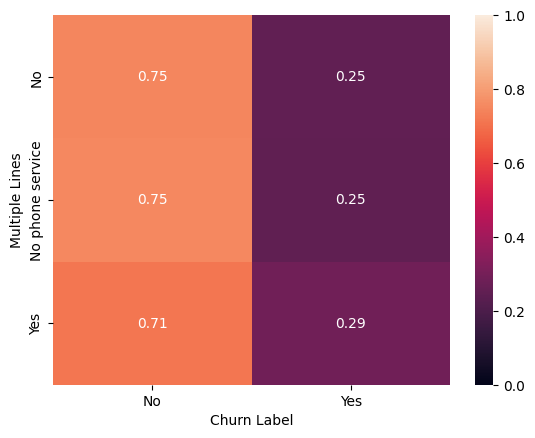

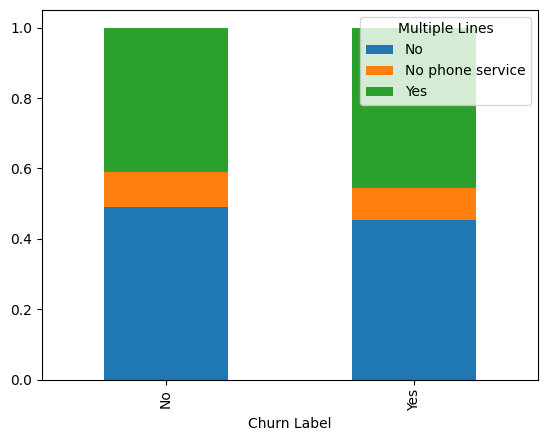


Variable: Internet Service
Churn Label             No       Yes
Internet Service                    
DSL               0.810409  0.189591
Fiber optic       0.581072  0.418928
No                0.925950  0.074050


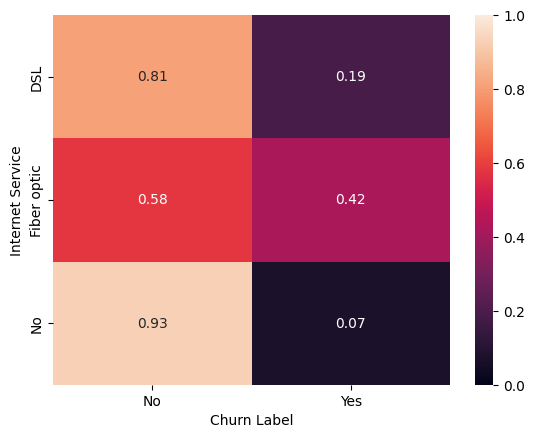

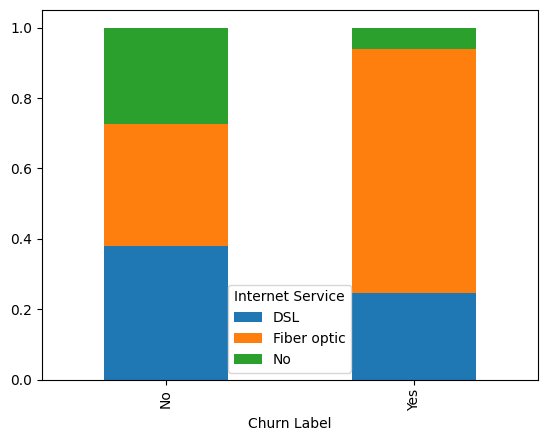


Variable: Online Security
Churn Label                No       Yes
Online Security                        
No                   0.582333  0.417667
No internet service  0.925950  0.074050
Yes                  0.853888  0.146112


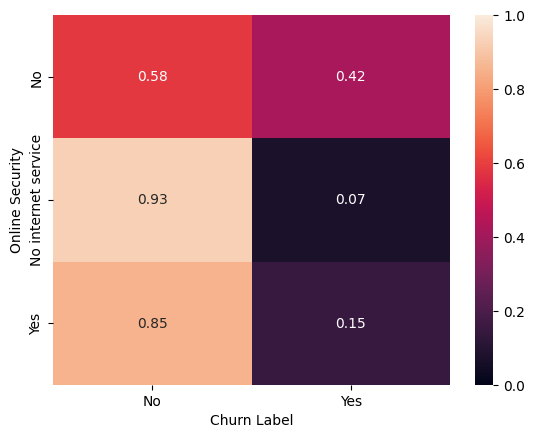

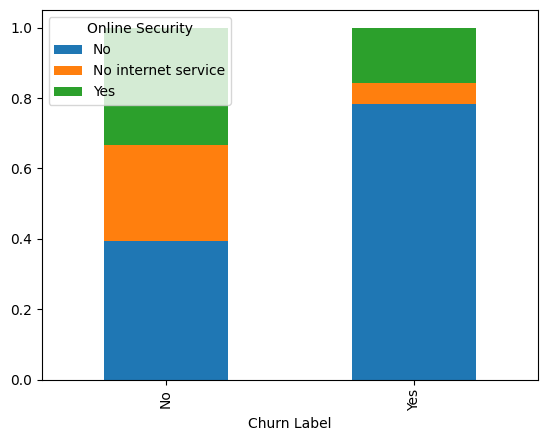


Variable: Online Backup
Churn Label                No       Yes
Online Backup                          
No                   0.600712  0.399288
No internet service  0.925950  0.074050
Yes                  0.784685  0.215315


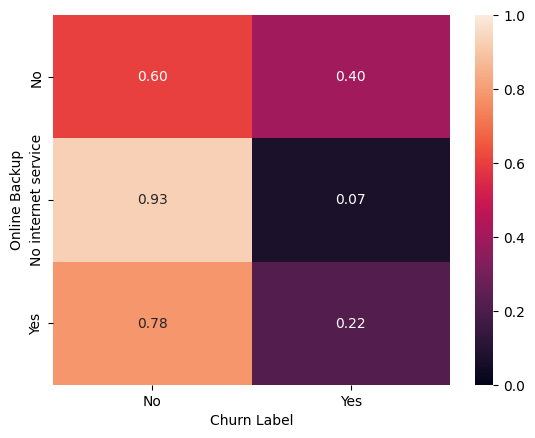

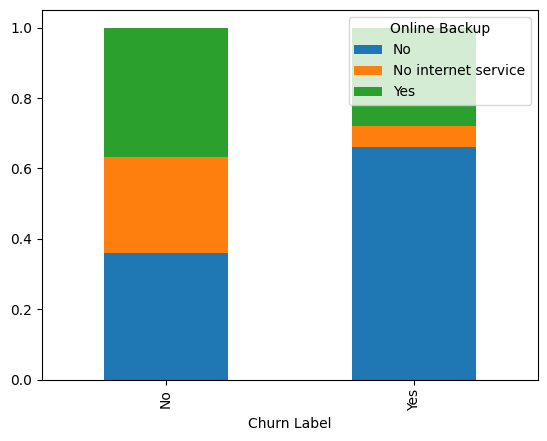


Variable: Device Protection
Churn Label                No       Yes
Device Protection                      
No                   0.608724  0.391276
No internet service  0.925950  0.074050
Yes                  0.774979  0.225021


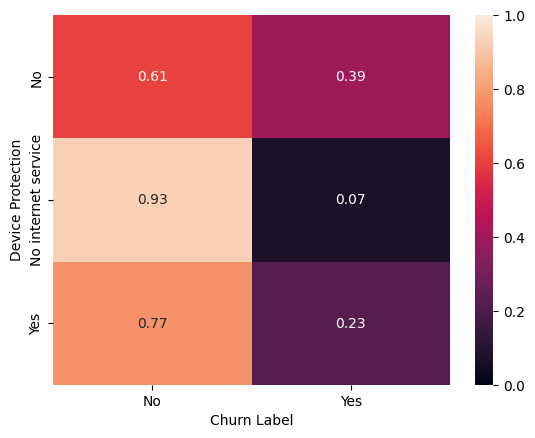

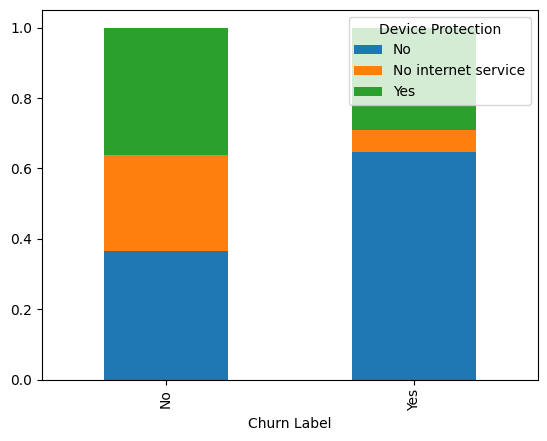


Variable: Tech Support
Churn Label                No       Yes
Tech Support                           
No                   0.583645  0.416355
No internet service  0.925950  0.074050
Yes                  0.848337  0.151663


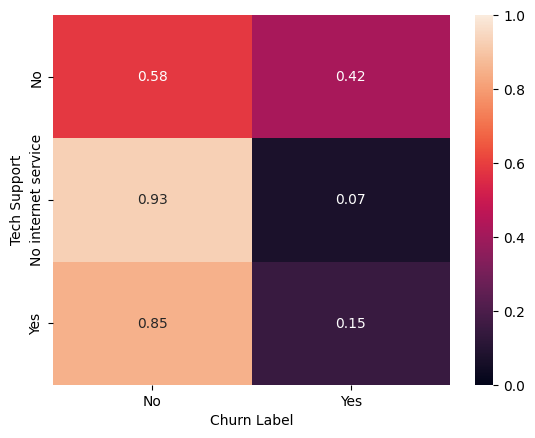

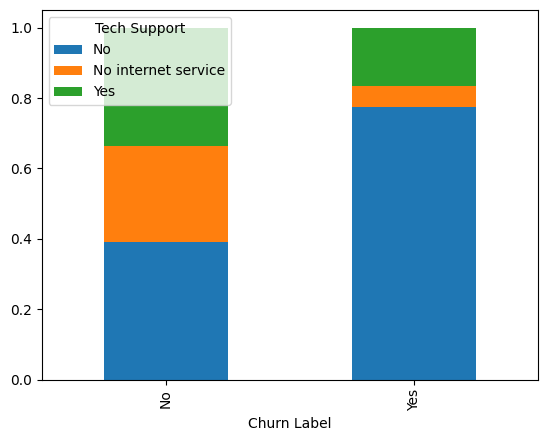


Variable: Streaming TV
Churn Label                No       Yes
Streaming TV                           
No                   0.664769  0.335231
No internet service  0.925950  0.074050
Yes                  0.699298  0.300702


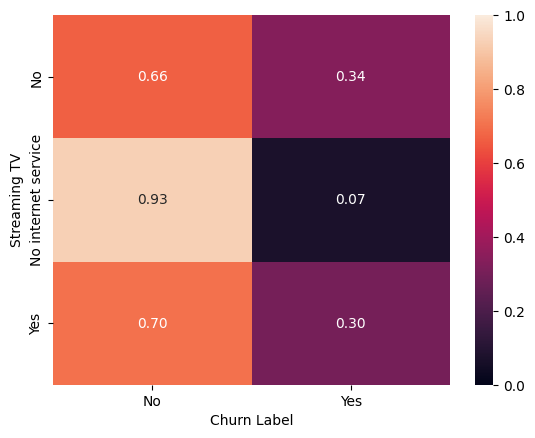

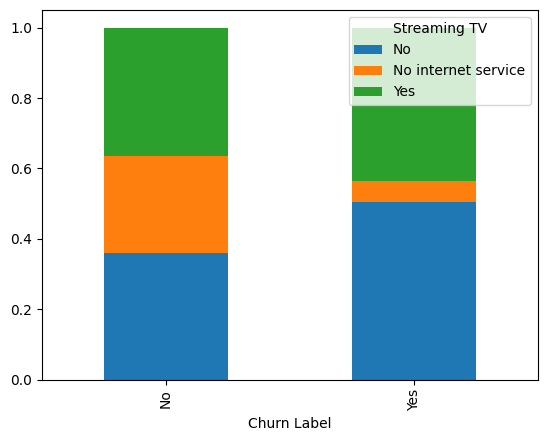


Variable: Streaming Movies
Churn Label                No       Yes
Streaming Movies                       
No                   0.663196  0.336804
No internet service  0.925950  0.074050
Yes                  0.700586  0.299414


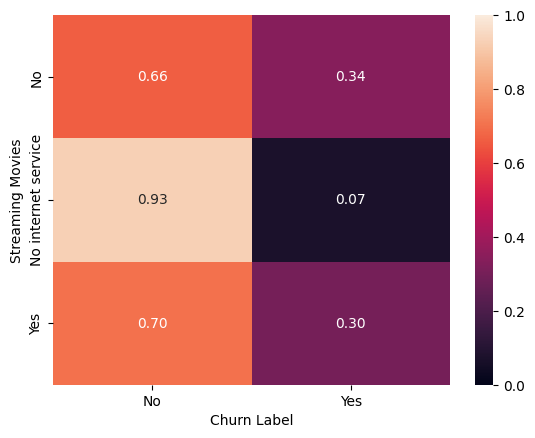

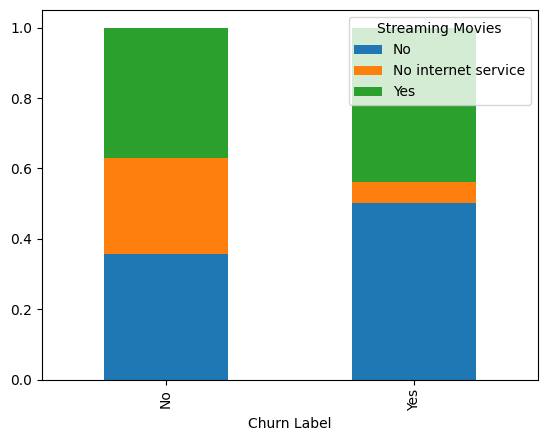


Variable: Contract
Churn Label           No       Yes
Contract                          
Month-to-month  0.572903  0.427097
One year        0.887305  0.112695
Two year        0.971681  0.028319


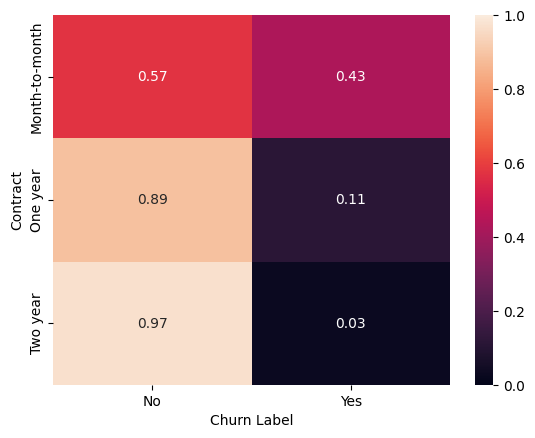

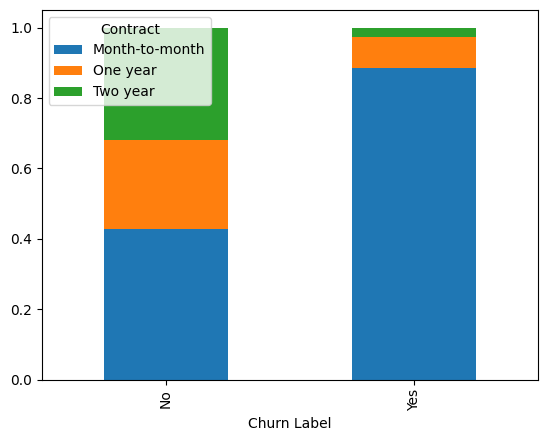


Variable: Paperless Billing
Churn Label              No       Yes
Paperless Billing                    
No                 0.836699  0.163301
Yes                0.664349  0.335651


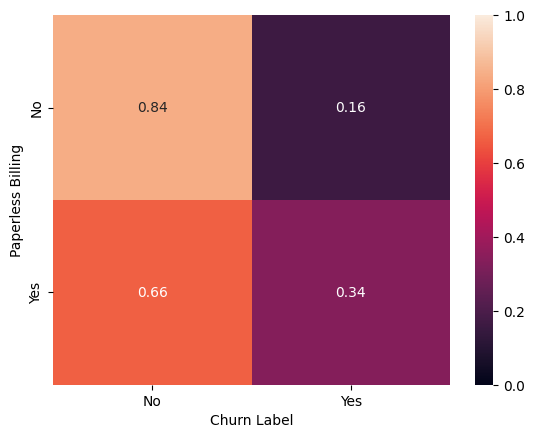

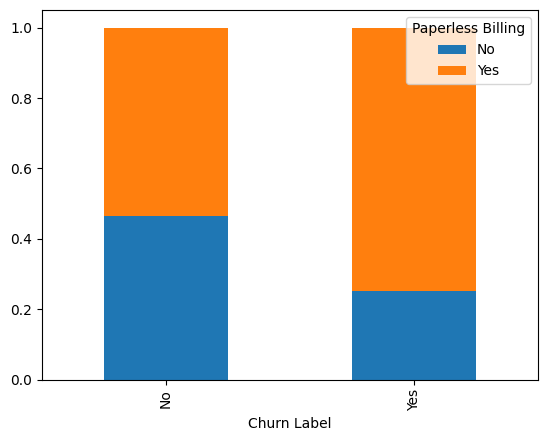


Variable: Payment Method
Churn Label                      No       Yes
Payment Method                               
Bank transfer (automatic)  0.832902  0.167098
Credit card (automatic)    0.847569  0.152431
Electronic check           0.547146  0.452854
Mailed check               0.808933  0.191067


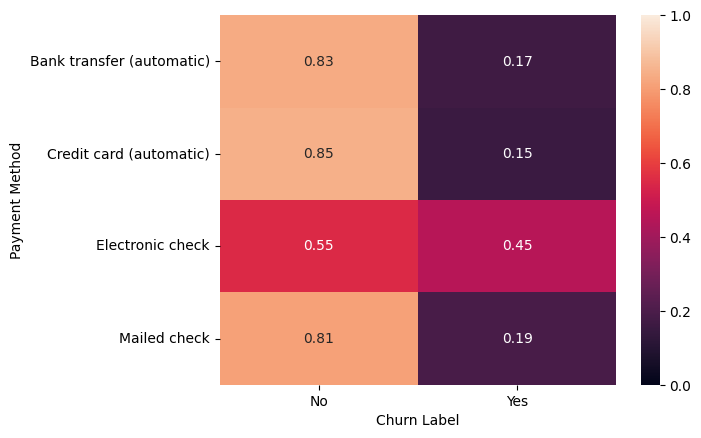

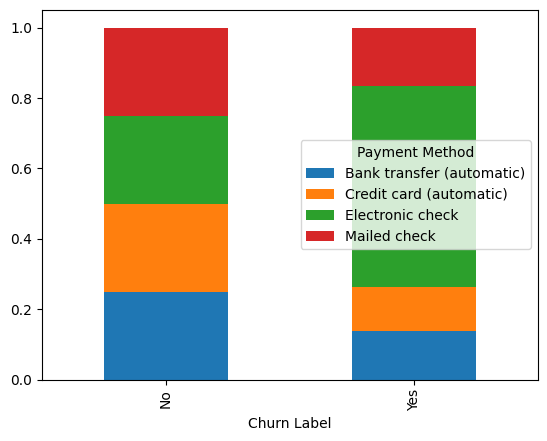

In [23]:
# Relación entre variables cualitativas y Churn Label (variable objetivo)
cat_vars_bi = [c for c in df.select_dtypes(include=['object']).columns
               if c not in ['Churn Label', 'Churn Reason']]

for cat in cat_vars_bi:
    print(f"\n{'='*60}")
    print(f"Variable: {cat}")
    print('='*60)

    tabla = pd.crosstab(df[cat], df['Churn Label'], normalize='index')
    print(tabla)

    plt.figure()
    sns.heatmap(tabla, annot=True, fmt='.2f', vmin=0, vmax=1)
    plt.show()

    tabla2 = pd.crosstab(df['Churn Label'], df[cat], normalize='index')
    tabla2.plot.bar(stacked=True)
    plt.show()

### Respuestas - Paso 6

Entre las variables cuantitativas, Tenure Months es la mejor predictora (correlación −0.352) porque los clientes que cancelan tienen en promedio 18 meses, mientras que los que permanecen tienen 37.6 meses. Luego siguen Monthly Charges (+0.193) y Total Charges (−0.199). Churn Score tiene una correlación muy alta (~0.665), pero no debe usarse porque ya está basado en una estimación del churn y podría sesgar el modelo. CLTV es la variable más débil (−0.127).

Entre las variables cualitativas, Contract es la que más diferencia a los clientes (42.7% de churn en contratos mes a mes vs 2.8% en contratos de dos años). También destacan Payment Method (cheque electrónico: 45.3% churn), Internet Service (fibra óptica: 41.9%) y Online Security y Tech Support (sin servicio: ~42% churn). Senior Citizen, Paperless Billing y Dependents también muestran diferencias. En cambio, Gender, Phone Service y las variables geográficas casi no aportan capacidad predictiva.